In [1]:
!git clone https://github.com/Arijit1080/Licence-Plate-Detection-using-YOLO-V8.git

Cloning into 'Licence-Plate-Detection-using-YOLO-V8'...
remote: Enumerating objects: 133, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 133 (delta 4), reused 8 (delta 3), pack-reused 117 (from 1)
Receiving objects: 100% (133/133), 14.73 MiB | 16.37 MiB/s, done.
Resolving deltas: 100% (34/34), done.


In [2]:
cd /content/Licence-Plate-Detection-using-YOLO-V8

/content/Licence-Plate-Detection-using-YOLO-V8


In [2]:
!nvidia-smi

Sun Mar 16 11:11:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install roboflow ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.5/84.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.2/949.2 kB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.

In [4]:
from roboflow import Roboflow
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display

display.clear_output()

rf = Roboflow(api_key="xxxxxxx")  #replace with you API KEY
project = rf.workspace("my-space-p2eer").project("licenseplate-apu6u-mt4ow")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to LicensePlate-1 in yolov8:: 100%|██████████| 4012/4012 [00:00<00:00, 4972.98it/s]


Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/cfg/__init__.py", line 920, in entrypoint
    raise ValueError(f"Invalid 'mode={mode}'. Valid modes are {MODES}.\n{CLI_HELP_MSG}")
ValueError: Invalid 'mode=<module 'ultralytics.utils.checks' from '/usr/local/lib/python3.11/dist-packages/ultralytics/utils/checks.py'>'. Valid modes are frozenset({'benchmark', 'export', 'track', 'predict', 'train', 'val'}).

    Arguments received: ['yolo', 'mode=checks']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of frozenset({'classify', 'segment', 'detect', 'obb', 'pose'})
                MODE (required) is one of frozenset({'benchmark', 'export', 'track', 'predict', 'train', 'val'})
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' tha

In [5]:
!yolo task=detect mode=train model=yolov8n.pt data=/content/LicensePlate-1/data.yaml epochs=80 imgsz=640

100% 6.25M/6.25M [00:00<00:00, 126MB/s]
Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/LicensePlate-1/data.yaml, epochs=80, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=Fals

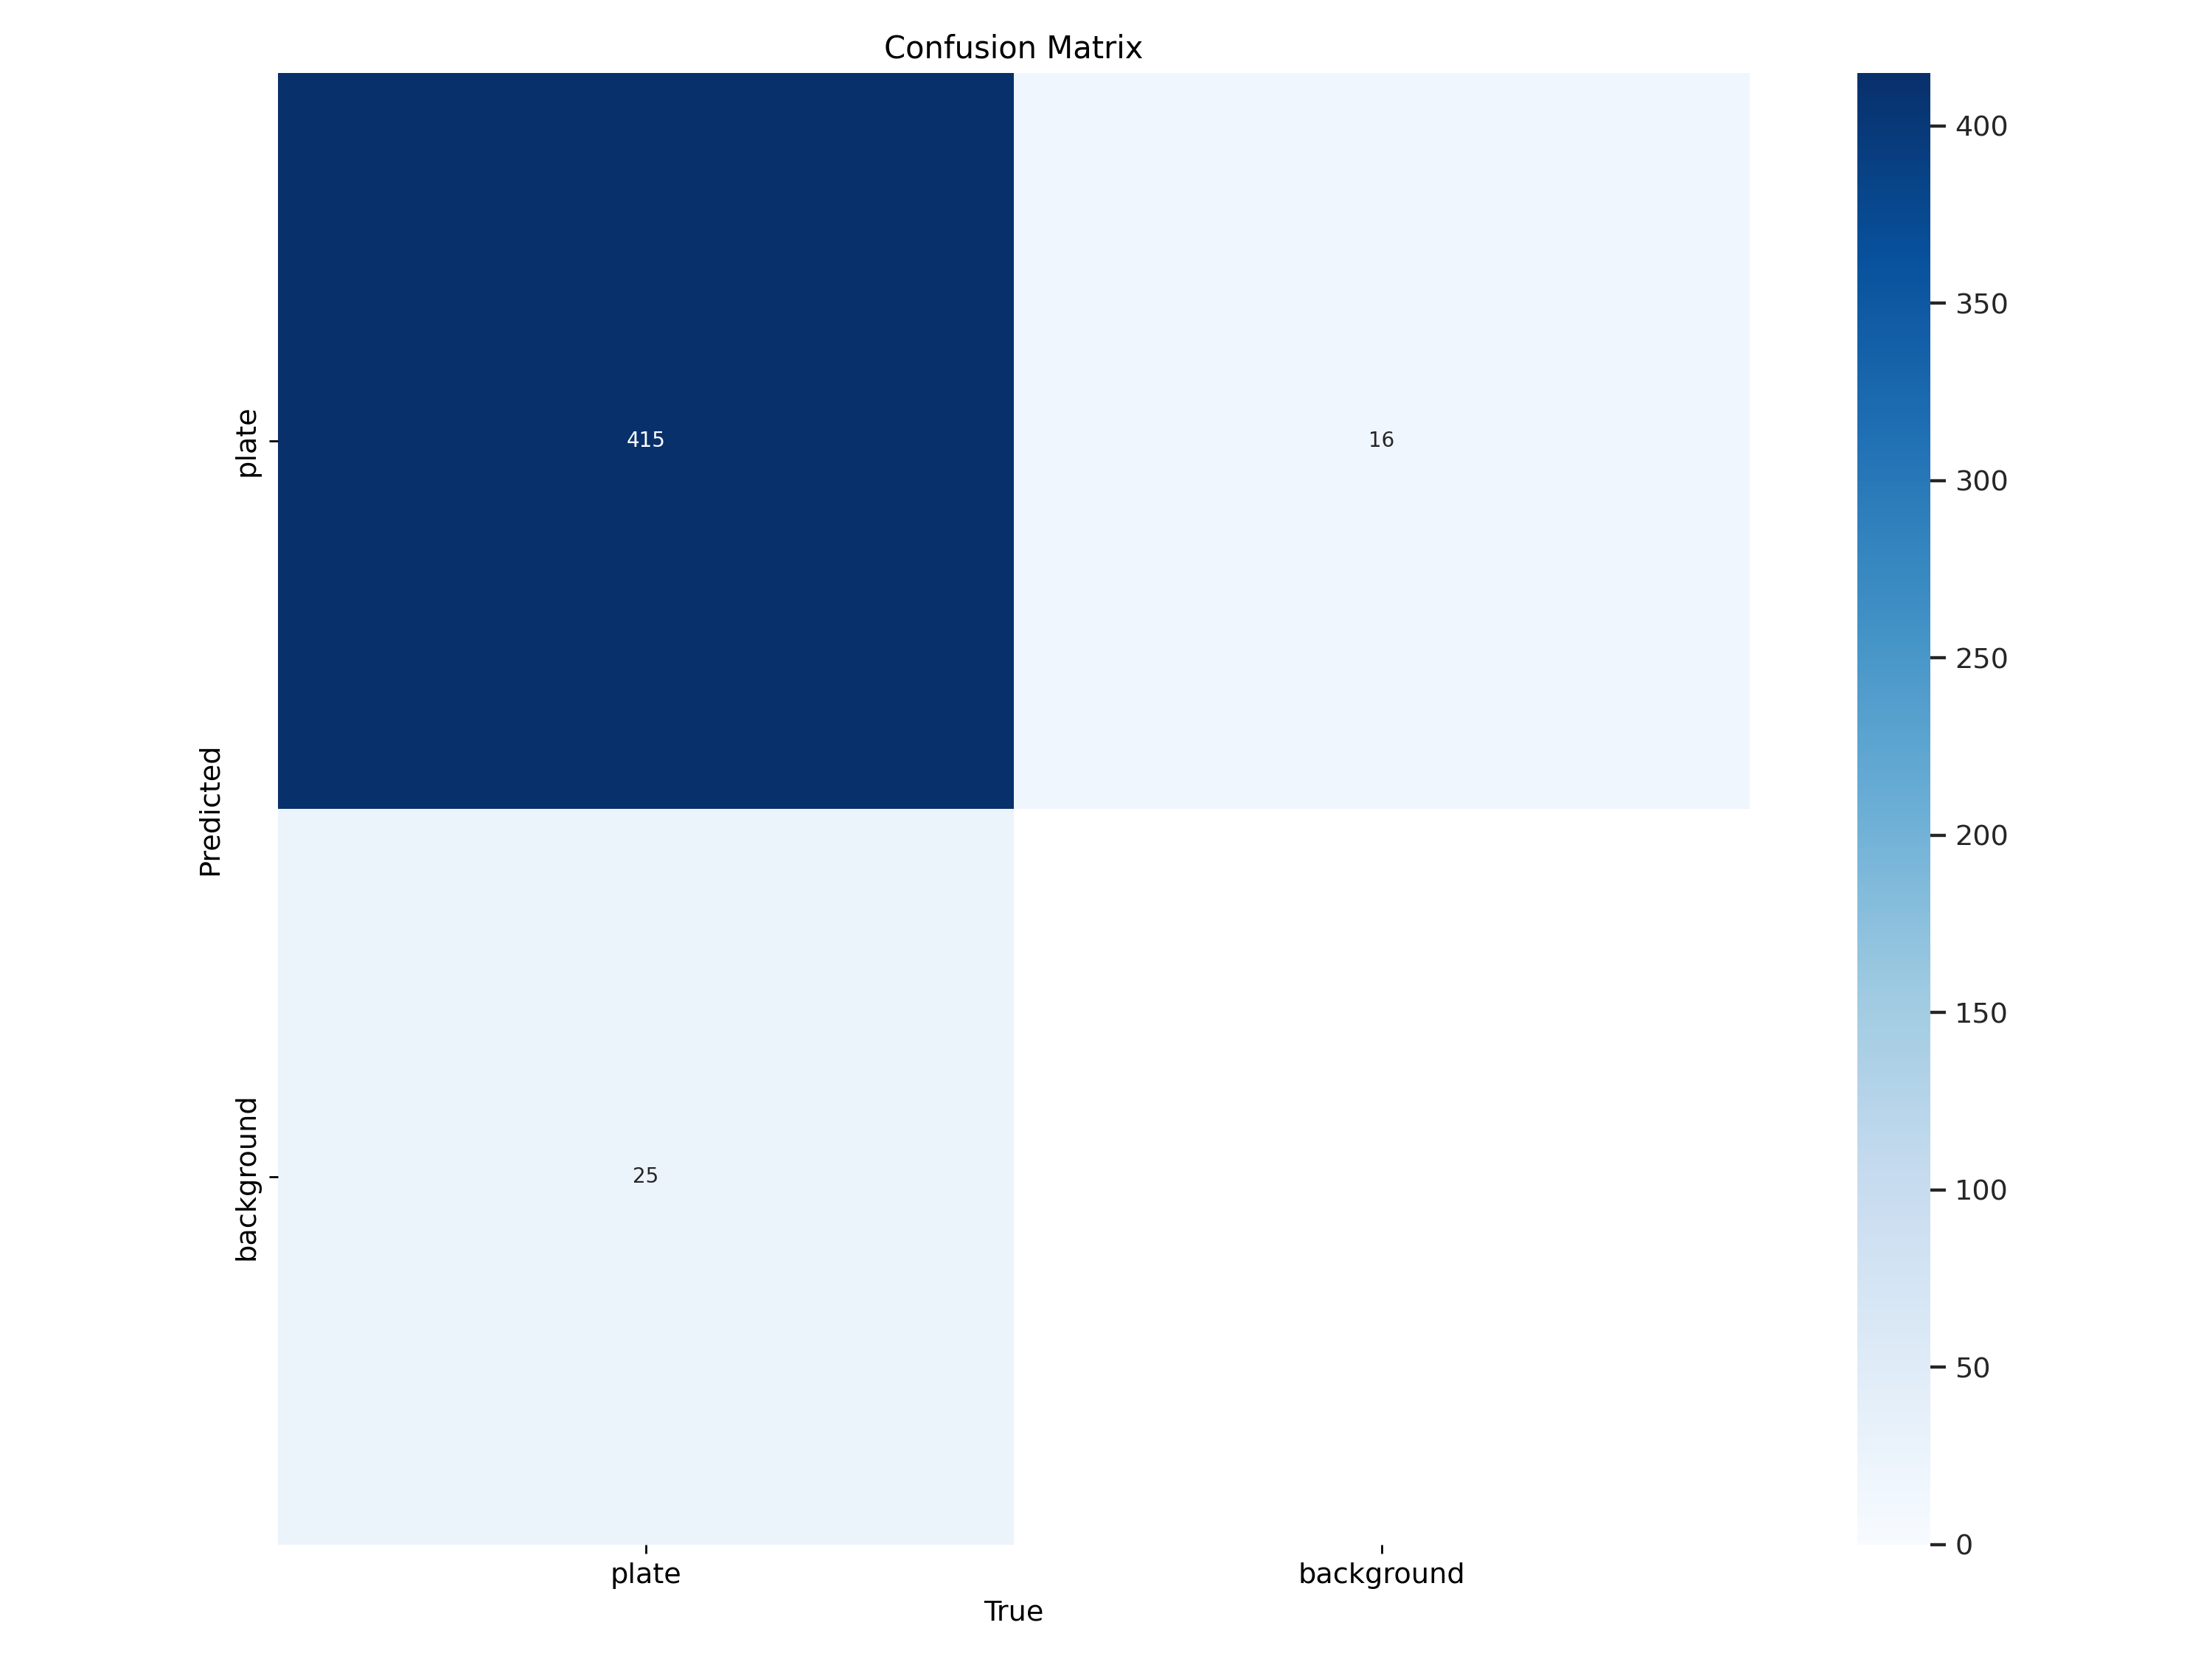

In [6]:
Image(filename=f'/content/runs/detect/train/confusion_matrix.png', width = 600)

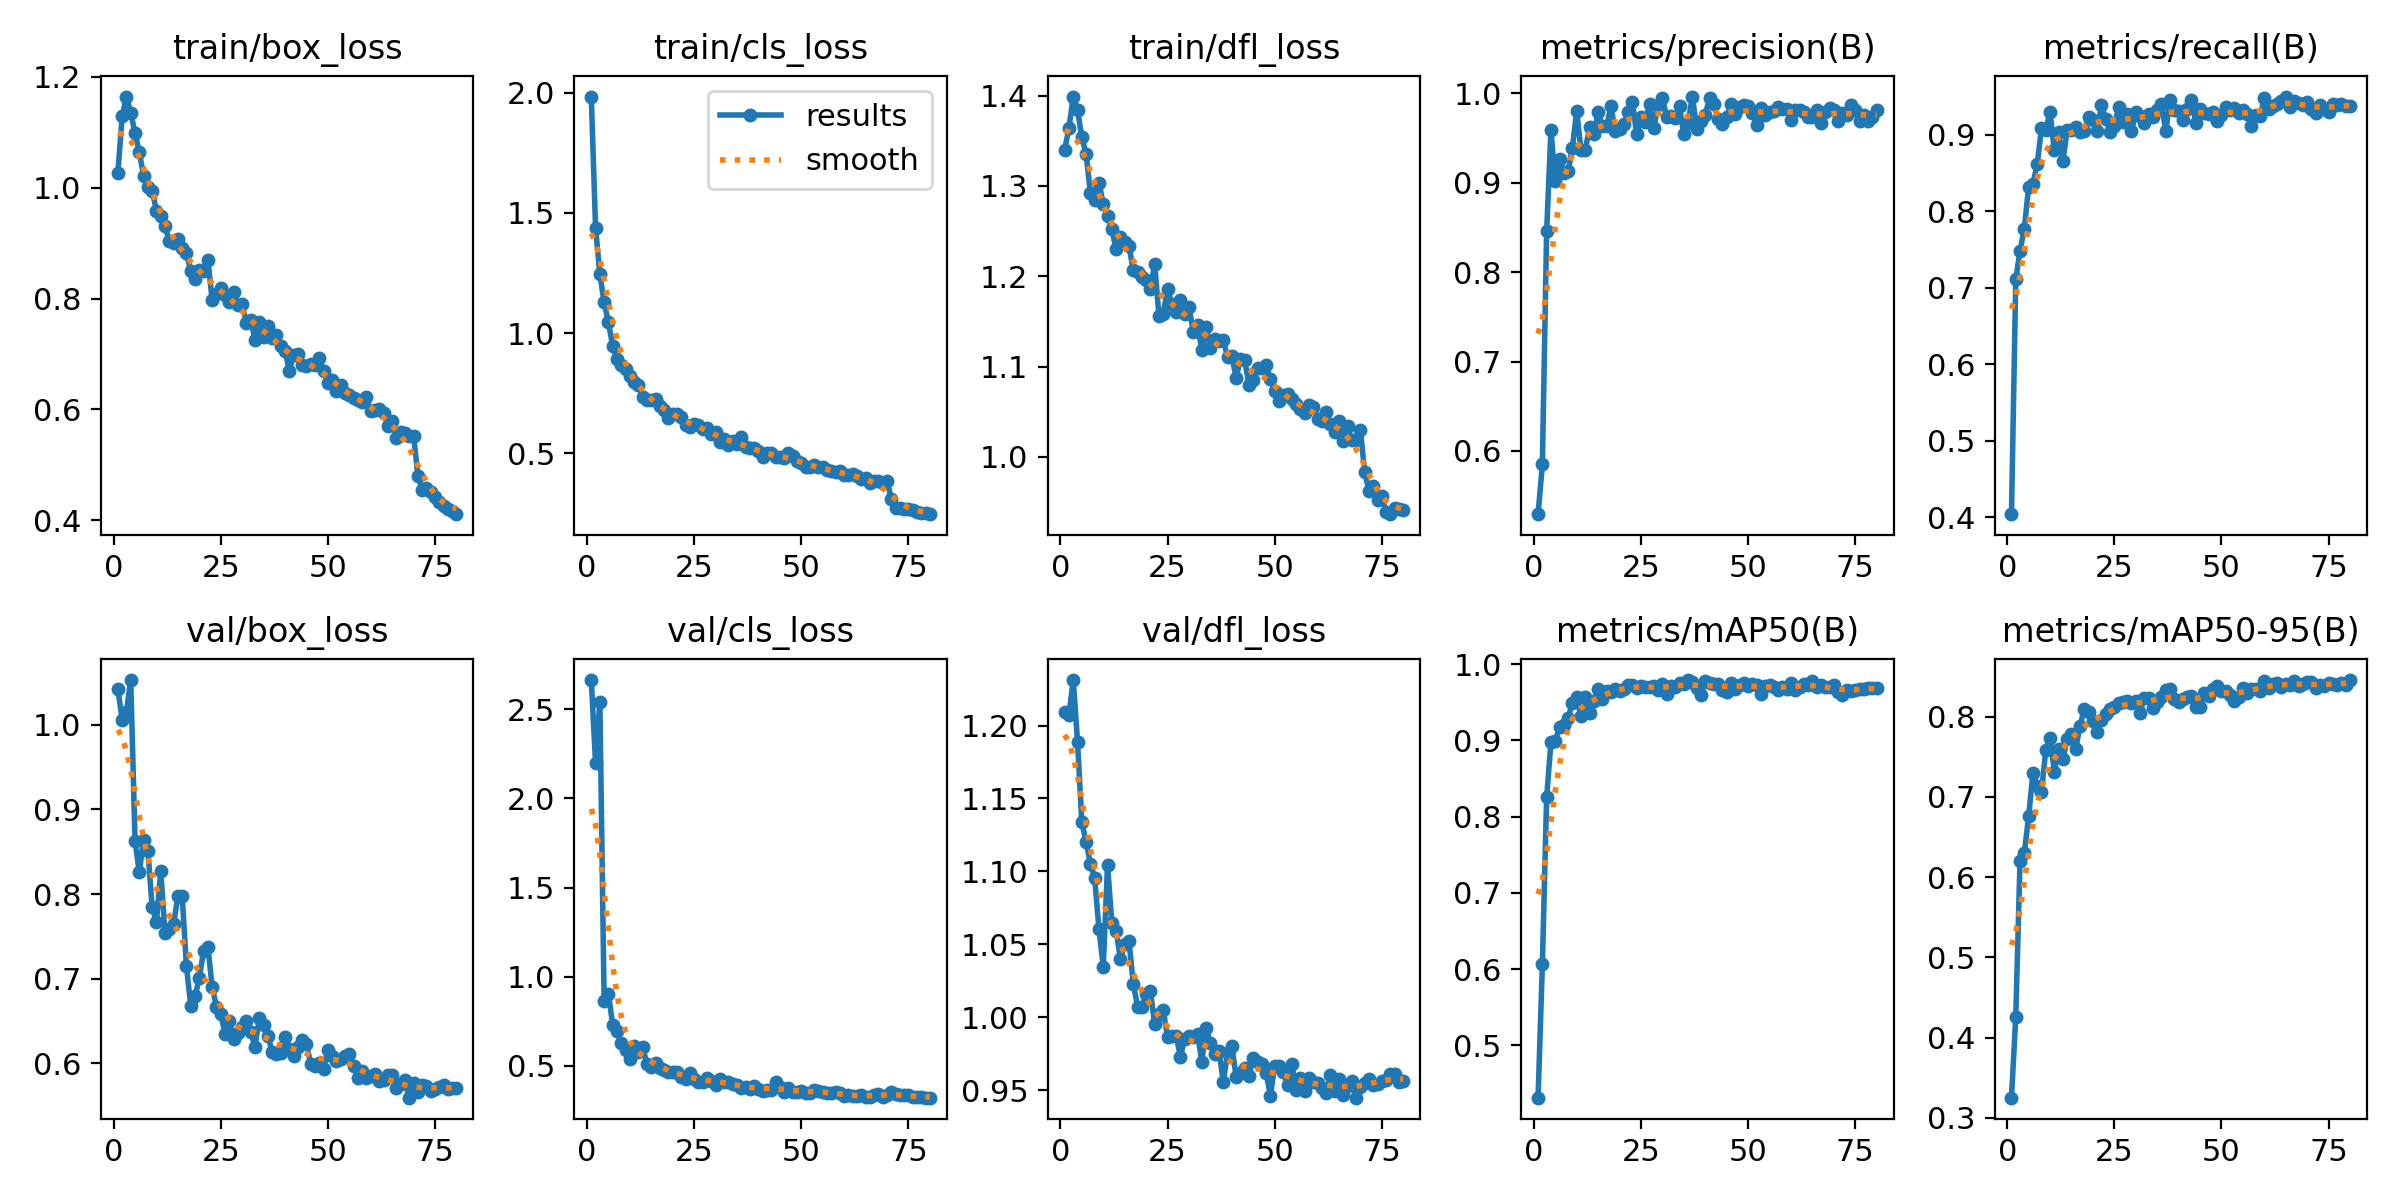

In [7]:
Image(filename=f'/content/runs/detect/train/results.png', width = 600)

In [9]:
!yolo task=detect mode=val model=/content/runs/detect/train/weights/best.pt data=/content/LicensePlate-1/data.yaml

Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Scanning /content/LicensePlate-1/valid/labels.cache... 402 images, 0 backgrounds, 0 corrupt: 100% 402/402 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 391, len(boxes) = 440. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 26/26 [00:05<00:00,  4.55it/s]
                   all        402        440      0.981      0.938      0.969      0.846
Speed: 0.8ms preprocess, 5.0ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs/detect/val2
💡 Learn more at https://docs.ultralytics.com/modes/val


In [11]:
!yolo task=detect mode=predict model=/content/runs/detect/train/weights/best.pt conf=0.5 source=/content/LicensePlate-1/test/images/

Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

image 1/199 /content/LicensePlate-1/test/images/00bc6c35-3eec-4fb5-bdd3-e5d8656b014f_jpg.rf.9c62299a9580a8a81feb7cf811ff6a76.jpg: 640x640 1 plate, 8.8ms
image 2/199 /content/LicensePlate-1/test/images/011d8b71-8bb9-4c8e-8b10-89952740b973_jpg.rf.219ec29ed82947083b03a7e5fd3652e0.jpg: 640x640 1 plate, 7.5ms
image 3/199 /content/LicensePlate-1/test/images/04977a14-f268-4d31-8675-902e662b6b00_jpg.rf.c16f36c15bff0a9da57e7fa89b0dc223.jpg: 640x640 1 plate, 7.3ms
image 4/199 /content/LicensePlate-1/test/images/05416ac5-4757-492d-b47a-9d993cd47b61_jpg.rf.8e000036ea0c3055a6a2f3a10c2f0e6e.jpg: 640x640 1 plate, 7.4ms
image 5/199 /content/LicensePlate-1/test/images/0afbc792-24e8-4554-bd69-b042897f2c96_jpg.rf.e13ce9cd7f79759c5a77237837774ac3.jpg: 640x640 1 plate, 7.3ms
image 6/199 /content/LicensePlate-1/test/images/0c6354e9-6668-4351-92ea-

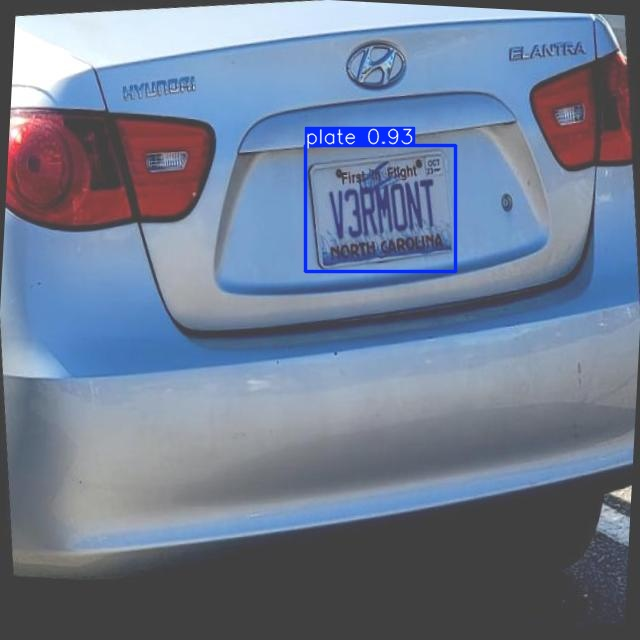

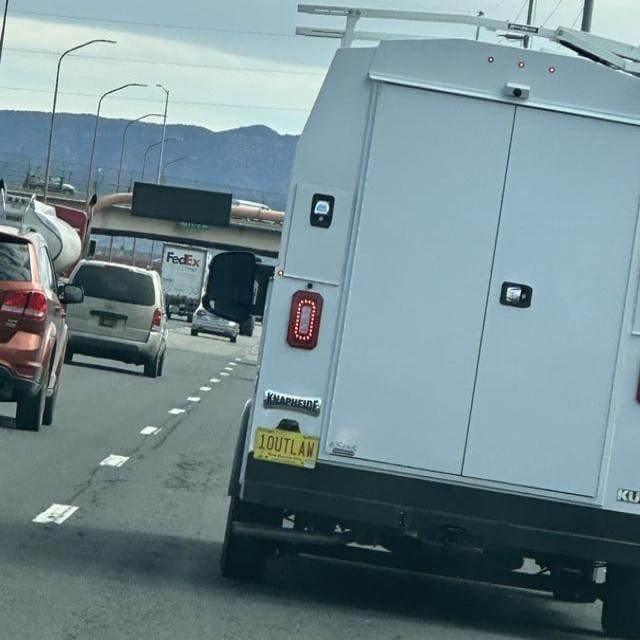

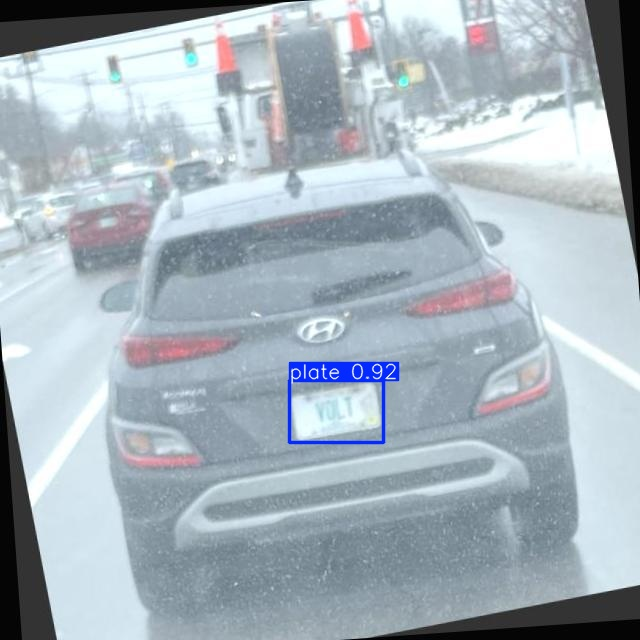

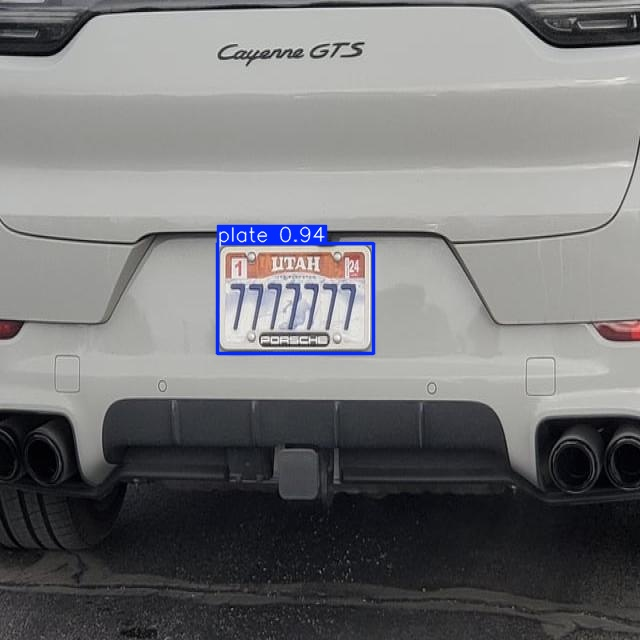

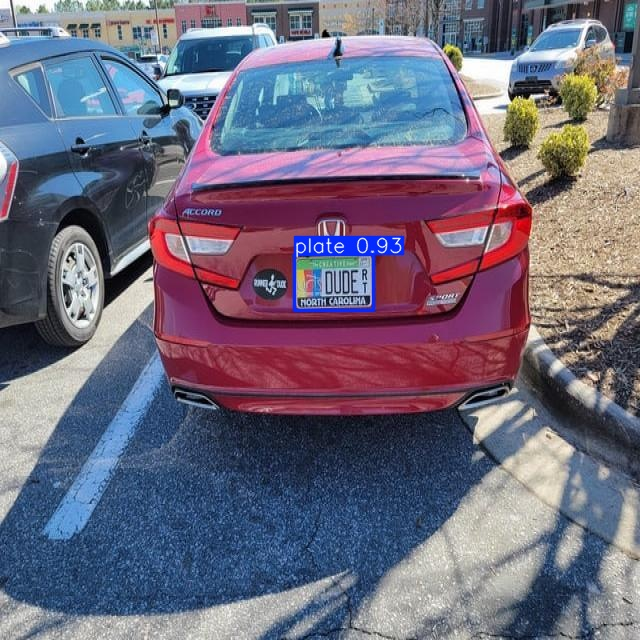

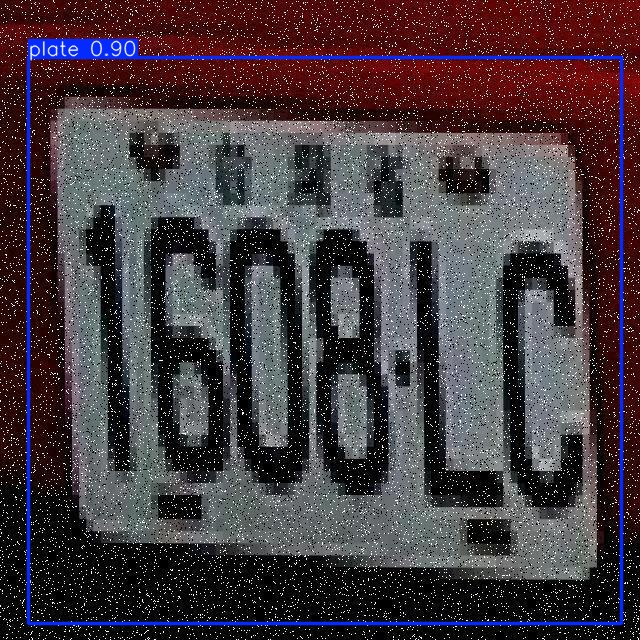

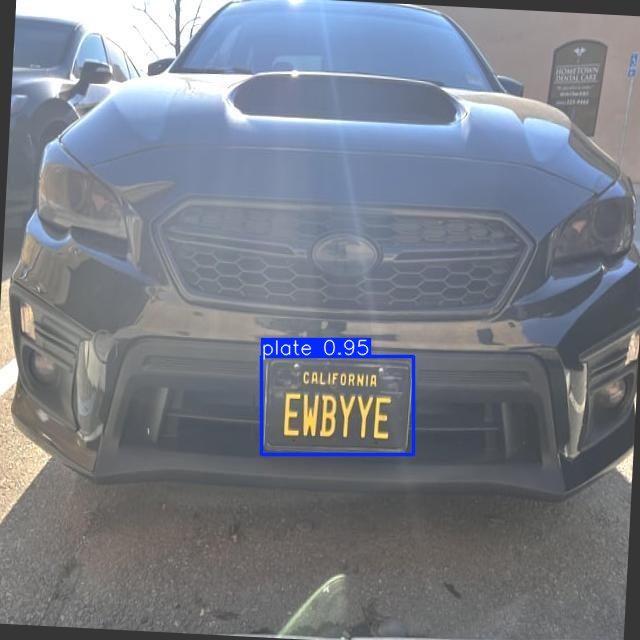

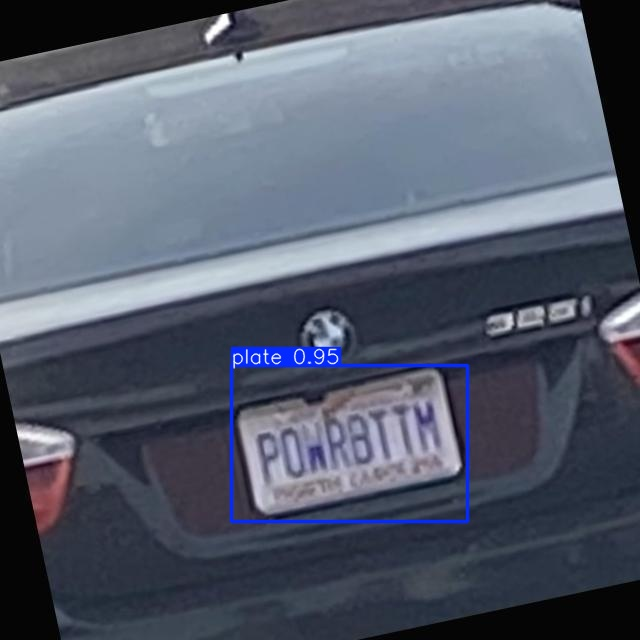

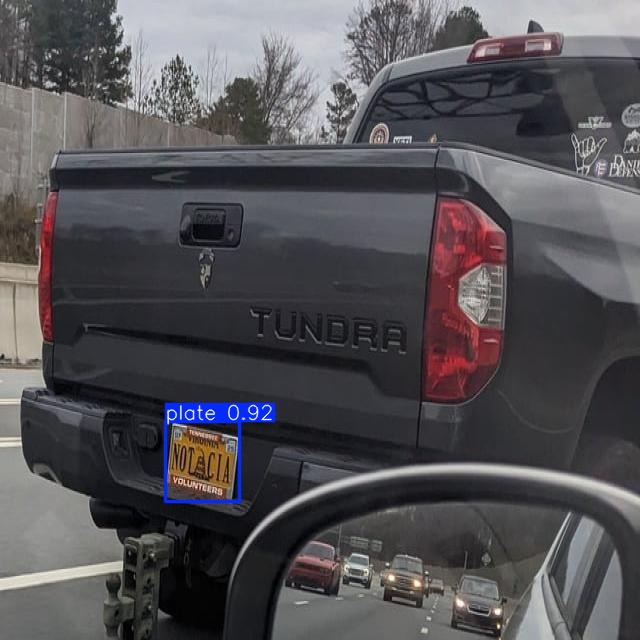

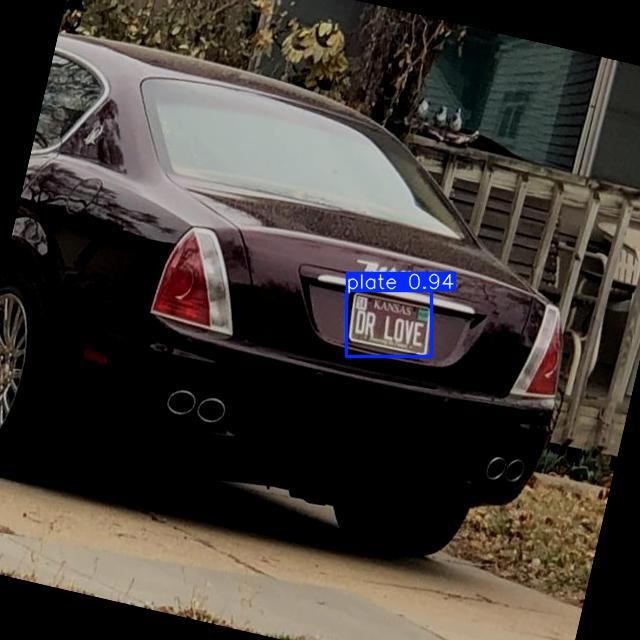

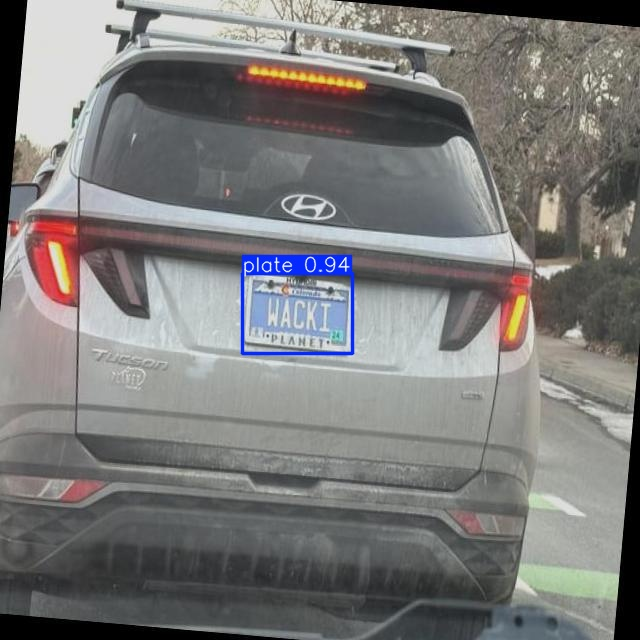

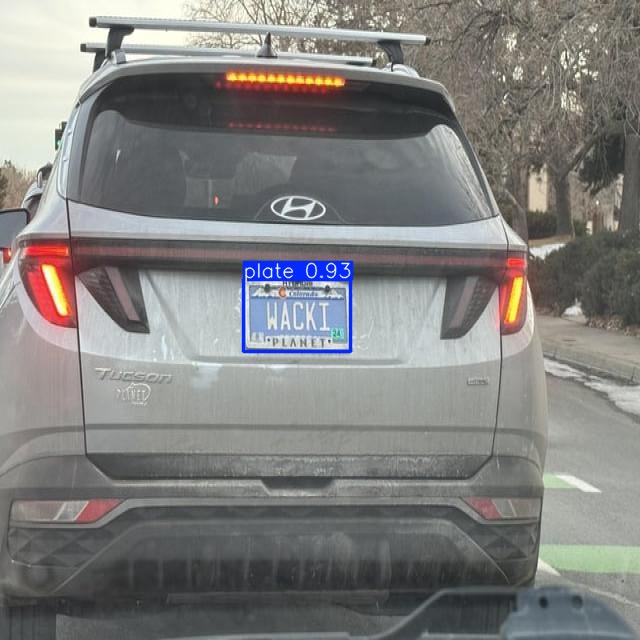

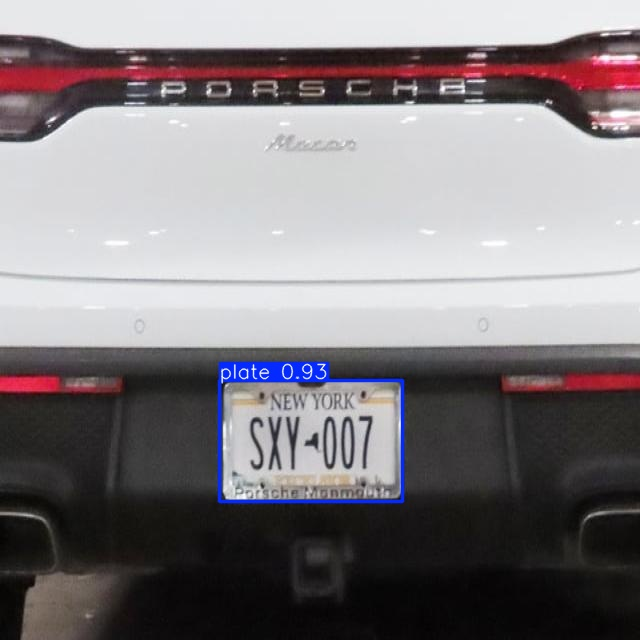

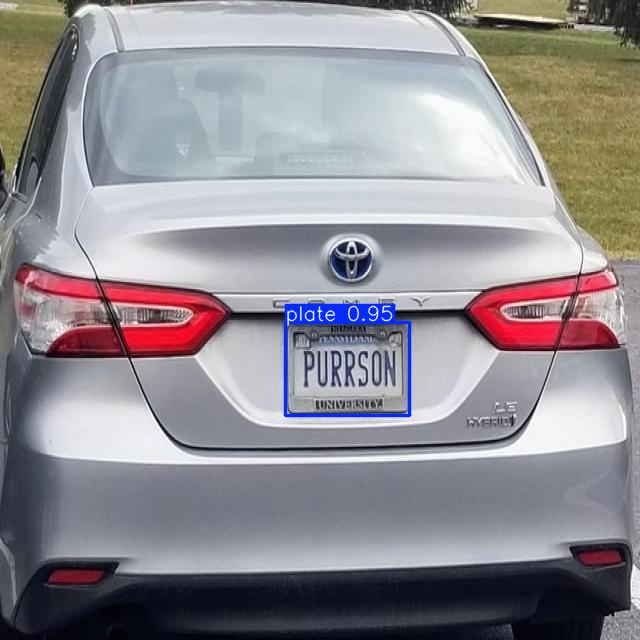

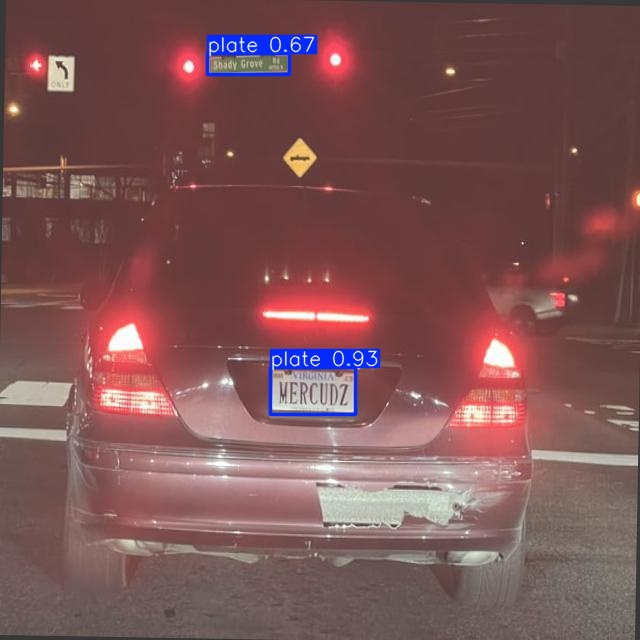

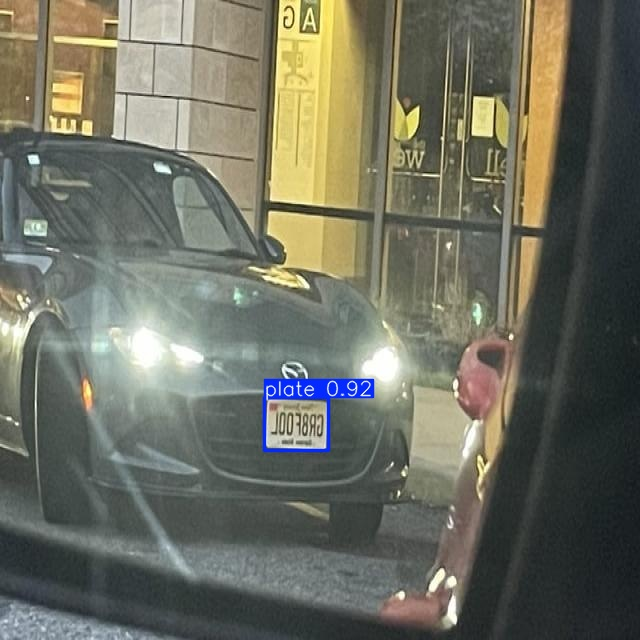

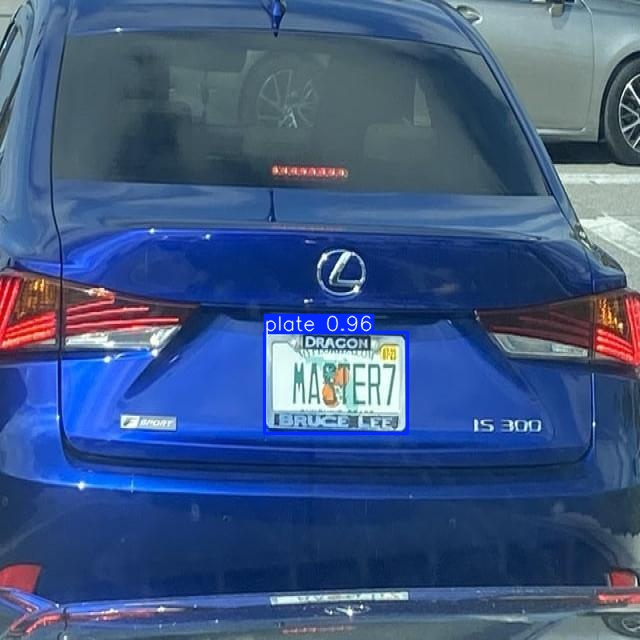

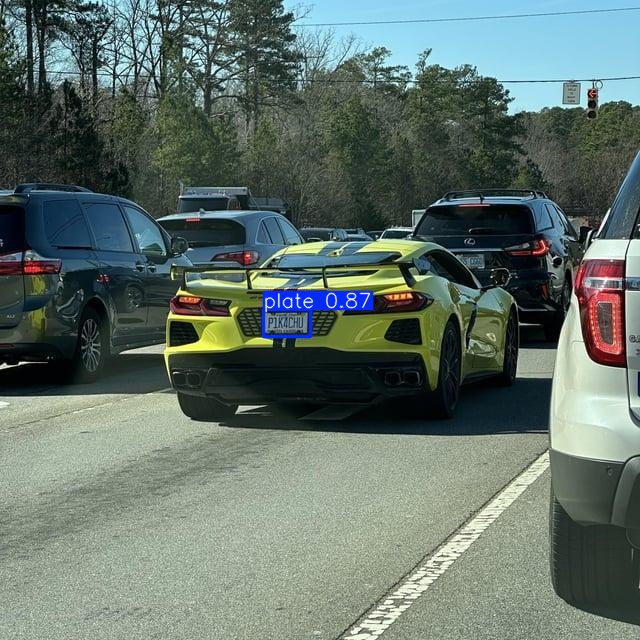

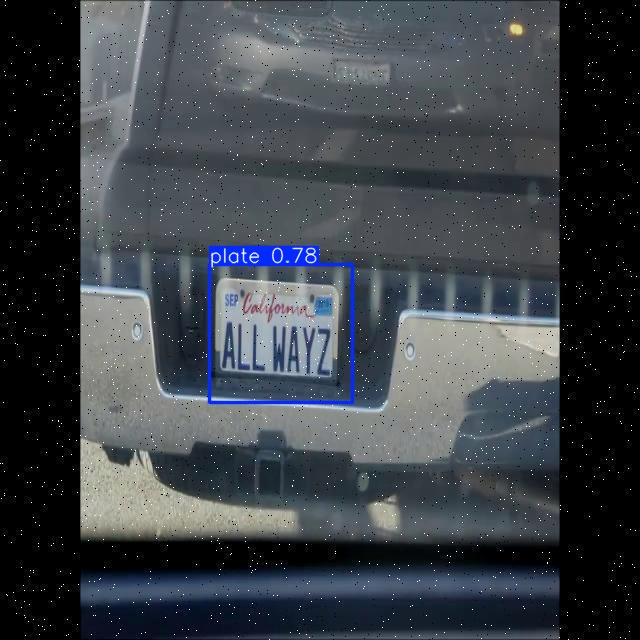

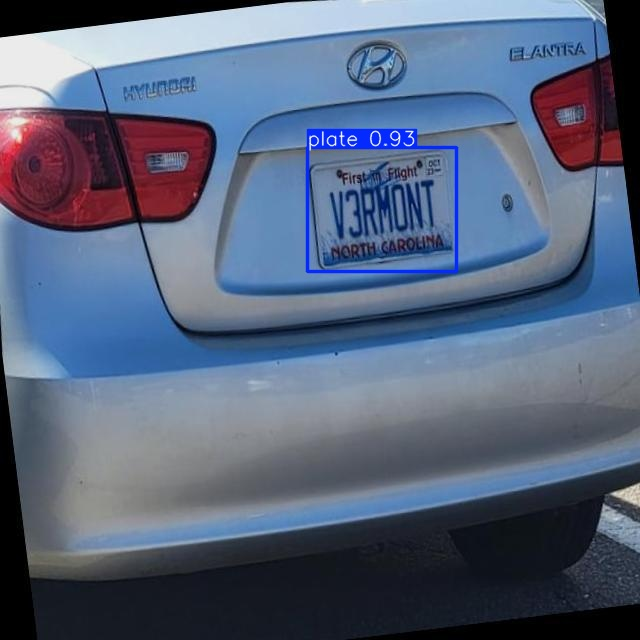

In [16]:
import glob
from IPython.display import Image, display
for image_path in glob.glob('/content/runs/detect/predict/*.jpg')[:20]:
  display(Image(filename=image_path, width=600))
  print("\n")

In [29]:
!pip install --no-cache-dir "sng4onnx>=1.0.1" "onnxslim>=0.1.31" "tflite_support" "onnxruntime" "protobuf" --extra-index-url https://pypi.ngc.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 MB 268.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 284.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 318.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.3/243.3 kB 288.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 189.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 284.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.6
    Uninstalling protobuf-4.25.6:
      Successfully uninstalled protobuf-4.25.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-metadata 1.16.

In [2]:
!pip install ai-edge-litert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 44.4 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
model=YOLO('/content/runs/detect/train/weights/best.pt')
model.export(format='tflite')

Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)

TensorFlow SavedModel: starting export with tensorflow 2.18.0...


100%|██████████| 1.11M/1.11M [00:00<00:00, 28.3MB/s]
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /content/calibration_image_sample_data_20x128x128x3_float32.npy...: 100%|██████████| 1/1 [00:00<00:00, 17.19file/s]



ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.48...
ONNX: export success ✅ 6.7s, saved as '/content/runs/detect/train/weights/best.onnx' (11.8 MB)
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.27.0...
TensorFlow SavedModel: export success ✅ 49.6s, saved as '/content/runs/detect/train/weights/best_saved_model' (30.1 MB)

TensorFlow Lite: starting export with tensorflow 2.18.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/content/runs/detect/train/weights/best_saved_model/best_float32.tflite' (11.7 MB)

Export complete (50.2s)
Results saved to /content/runs/detect/train/weights
Predict:         yolo predict task=detect model=/content/runs/detect/train/weights/best_saved_model/best_float32.tflite imgsz=640  
Validate:        yolo val task=detect model=/content/runs/detect/train/weights/best_saved_model/best_float32.tflite imgsz=640 data=/content/LicensePlate-1/data.yaml  
Visualize:       https://netron.app


'/content/runs/detect/train/weights/best_saved_model/best_float32.tflite'